# Visualize HPE Results from moveEnet_flowKalman.cpp

This notebook loads predictions from CSV (eval_format) and ground truth from YARP log, computes metrics (PCK, RMSE, MPJPE), and visualizes joint trajectories, skeleton overlays, and PCK curves for dataset cam2_S1_Discussion_ch0.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from pathlib import Path
from datasets.utils import constants as ds_constants, parsing as ds_parsing
from evaluation.utils import metrics as metrics_utils

# Load CSV Data

In [2]:
pred_path = '/home/moveEnetFlow/csv_file/op0.05_np0.1_fp0.05/cam2_S8_Discussion.csv'
predictions = np.loadtxt(pred_path, delimiter=',', skiprows=1)
ncols = predictions.shape[1]
ts_pred = predictions[:, 0]

# Detect CSV layout (eval_format vs non-eval)
if ncols in (28, 54):
    # eval_format: ts, latency, 26 coords (x0,y0,...,x12,y12) [+ 26 velocities optional]
    lat_pred = predictions[:, 1]
    joints_pred = predictions[:, 2:28].reshape(-1, 13, 2)
    csv_layout = 'eval_format'
elif (ncols - 1) % 5 == 0:
    # non-eval: ts, then per-joint x,y,vx,vy,conf (5 values each)
    lat_pred = np.zeros_like(ts_pred)
    joints_pred = np.zeros((len(ts_pred), 13, 2))
    for j in range(13):
        base = 1 + j * 5
        joints_pred[:, j, 0] = predictions[:, base]
        joints_pred[:, j, 1] = predictions[:, base + 1]
    csv_layout = 'non_eval'
else:
    raise ValueError(f'Unrecognized CSV format with {ncols} columns: {pred_path}')

print(f"Loaded {len(ts_pred)} prediction frames ({csv_layout}, cols={ncols})")

Loaded 746 prediction frames (eval_format, cols=28)


# Load Log Data

In [3]:
gt_path = Path('/data/new_scarfGNN_full/raw/cam2_S8_Discussion/ch0GT200Hzskeleton/data.log')
data = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
print(f"Loaded GT data with {len(data['ts'])} frames")

Loaded GT data with 8253 frames


# Extract Joint Trajectories

In [4]:
ts_gt = np.concatenate(([0.0], data['ts'], [data['ts'][-1] + 1]))
for joint_key in ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys():
    x_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 0]], data[joint_key][:, 0], [data[joint_key][-1, 0]])))
    y_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 1]], data[joint_key][:, 1], [data[joint_key][-1, 1]])))
    data[joint_key] = {'x': x_interp, 'y': y_interp}

joints_gt = np.zeros((len(ts_pred), 13, 2))
joint_list = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, ts in enumerate(ts_pred):
    for j, joint in enumerate(joint_list):
        joints_gt[i, j, 0] = data[joint]['x'](ts)
        joints_gt[i, j, 1] = data[joint]['y'](ts)
print("Extracted GT joint trajectories")

Extracted GT joint trajectories


# Compute PCK Metric

In [5]:
if data['head_sizes'][0] != -1:
    pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['head_sizes'][0]], data['head_sizes'], [data['head_sizes'][-1]])))
else:
    pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['torso_sizes'][0]], data['torso_sizes'], [data['torso_sizes'][-1]])))
pck_sizes = pck_sizes_interp(ts_pred)

thresholds = [0.2,0.25,0.3,0.35, 0.4,0.45,0.5,0.55, 0.6]
pck_results = {}
for th in thresholds:
    pck_metric = metrics_utils.PCK(th)
    pck_metric.update_samples(joints_pred, joints_gt, pck_sizes)
    pck_results[th] = {'avg': pck_metric.get_value()}

print("PCK Results Summary:")
print("-" * 30)
for th in thresholds:
    overall_pck = pck_results[th]['avg'][1] * 100  # Overall PCK in percentage
    print(f"Threshold {th:.2f}: {overall_pck:.2f}%")
print("-" * 30)

PCK Results Summary:
------------------------------
Threshold 0.20: 93.41%
Threshold 0.25: 95.47%
Threshold 0.30: 96.97%
Threshold 0.35: 97.75%
Threshold 0.40: 98.46%
Threshold 0.45: 98.74%
Threshold 0.50: 99.16%
Threshold 0.55: 99.39%
Threshold 0.60: 99.55%
------------------------------


# Compute RMSE Metric

In [6]:
rmse_metric = metrics_utils.RMSE()
rmse_metric.update_samples(joints_pred, joints_gt)
rmse_results = rmse_metric.get_value()

print("RMSE Results Summary:")
print("-" * 40)
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, name in enumerate(joint_names):
    rmse_val = rmse_results[2][i]  # Per-joint RMSE
    print(f"{name}: {rmse_val:.2f} pixels")
print("-" * 40)
print(f"Total Average RMSE: {rmse_results[2].mean():.2f} pixels")
print("-" * 40)

RMSE Results Summary:
----------------------------------------
head: 2.33 pixels
shoulder_right: 2.32 pixels
shoulder_left: 2.49 pixels
elbow_right: 4.16 pixels
elbow_left: 4.53 pixels
hip_left: 1.66 pixels
hip_right: 1.95 pixels
wrist_right: 10.62 pixels
wrist_left: 10.20 pixels
knee_right: 1.54 pixels
knee_left: 1.35 pixels
ankle_right: 1.92 pixels
ankle_left: 1.52 pixels
----------------------------------------
Total Average RMSE: 3.58 pixels
----------------------------------------


# Compute MPJPE Metric

In [7]:
mpjpe_metric = metrics_utils.MPJPE()
mpjpe_metric.update_samples(joints_pred, joints_gt)
mpjpe_results = mpjpe_metric.get_value()

print("MPJPE Results Summary:")
print("-" * 40)
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, name in enumerate(joint_names):
    mpjpe_val = mpjpe_results[0][i]  # Per-joint MPJPE
    print(f"{name}: {mpjpe_val:.2f} pixels")
print("-" * 40)
print(f"Total Average MPJPE: {mpjpe_results[1]:.2f} pixels")
print("-" * 40)

MPJPE Results Summary:
----------------------------------------
head: 5.33 pixels
shoulder_right: 5.41 pixels
shoulder_left: 5.76 pixels
elbow_right: 8.73 pixels
elbow_left: 9.36 pixels
hip_left: 4.89 pixels
hip_right: 4.91 pixels
wrist_right: 19.28 pixels
wrist_left: 19.26 pixels
knee_right: 3.93 pixels
knee_left: 4.57 pixels
ankle_right: 5.85 pixels
ankle_left: 5.65 pixels
----------------------------------------
Total Average MPJPE: 7.92 pixels
----------------------------------------


# Generate PCK Curves

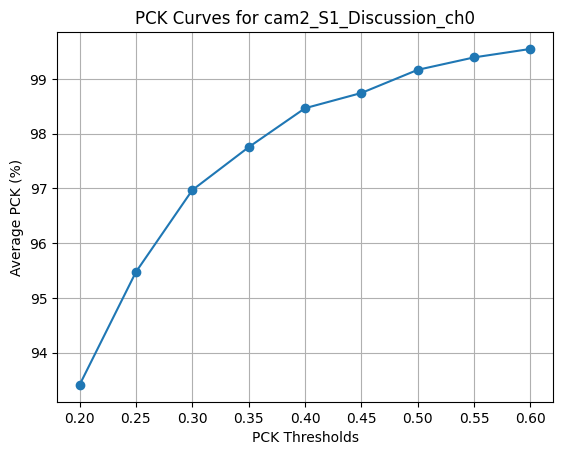

In [8]:
# thresholds = [0.2, 0.4, 0.6]
pck_vals = [pck_results[th]['avg'][1] * 100 for th in thresholds]  # to percentage, take overall avg
plt.figure()
plt.plot(thresholds, pck_vals, marker='o')
plt.xlabel('PCK Thresholds')
plt.ylabel('Average PCK (%)')
plt.title('PCK Curves for cam2_S1_Discussion_ch0')
plt.grid(True)
plt.show()

# Visualize Skeleton Overlays

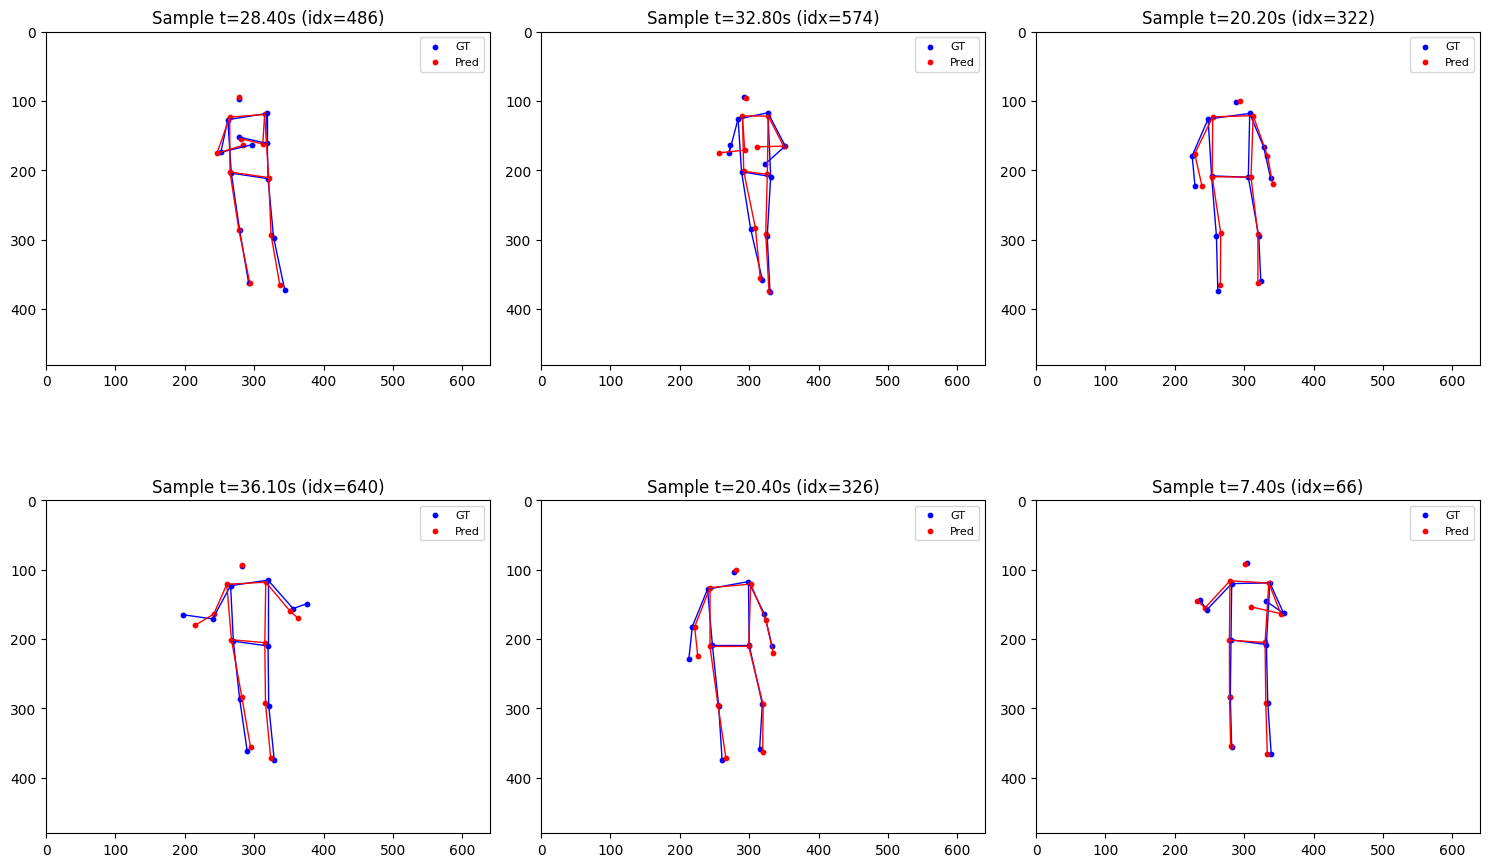

In [9]:
# Define skeleton connections (example, adjust as needed)
skeleton_connections = [
    (1, 2),   # shoulder_right to shoulder_left
    (1, 3),   # shoulder_right to elbow_right
    (1, 6),   # shoulder_right to hip_right
    (2, 4),   # shoulder_left to elbow_left
    (2, 5),   # shoulder_left to hip_left
    (3, 7),   # elbow_right to wrist_right
    (4, 8),   # elbow_left to wrist_left
    (5, 6),   # hip_left to hip_right
    (5, 10),  # hip_left to knee_left
    (6, 9),   # hip_right to knee_right
    (9, 11),  # knee_right to ankle_right
    (10, 12)  # knee_left to ankle_left
 ]

num_samples = 6
total_frames = len(ts_pred)
if total_frames == 0:
    raise ValueError('No prediction frames available to plot')

rng = np.random.default_rng(42)
sample_count = min(num_samples, total_frames)
sample_indices = rng.choice(total_frames, size=sample_count, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax_i, idx in enumerate(sample_indices):
    ax = axes[ax_i]
    # Plot GT
    for j in range(13):
        ax.scatter(joints_gt[idx, j, 0], joints_gt[idx, j, 1], c='blue', s=10, label='GT' if j == 0 else "")
    for conn in skeleton_connections:
        ax.plot([joints_gt[idx, conn[0], 0], joints_gt[idx, conn[1], 0]],
                [joints_gt[idx, conn[0], 1], joints_gt[idx, conn[1], 1]], c='blue', linewidth=1)
    # Plot Pred
    for j in range(13):
        ax.scatter(joints_pred[idx, j, 0], joints_pred[idx, j, 1], c='red', s=10, label='Pred' if j == 0 else "")
    for conn in skeleton_connections:
        ax.plot([joints_pred[idx, conn[0], 0], joints_pred[idx, conn[1], 0]],
                [joints_pred[idx, conn[0], 1], joints_pred[idx, conn[1], 1]], c='red', linewidth=1)

    ax.set_title(f'Sample t={ts_pred[idx]:.2f}s (idx={idx})')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.legend(loc='upper right', fontsize=8)

# Hide any unused subplots if < 6 samples
for k in range(sample_count, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()

# Visualize Joint Trajectories

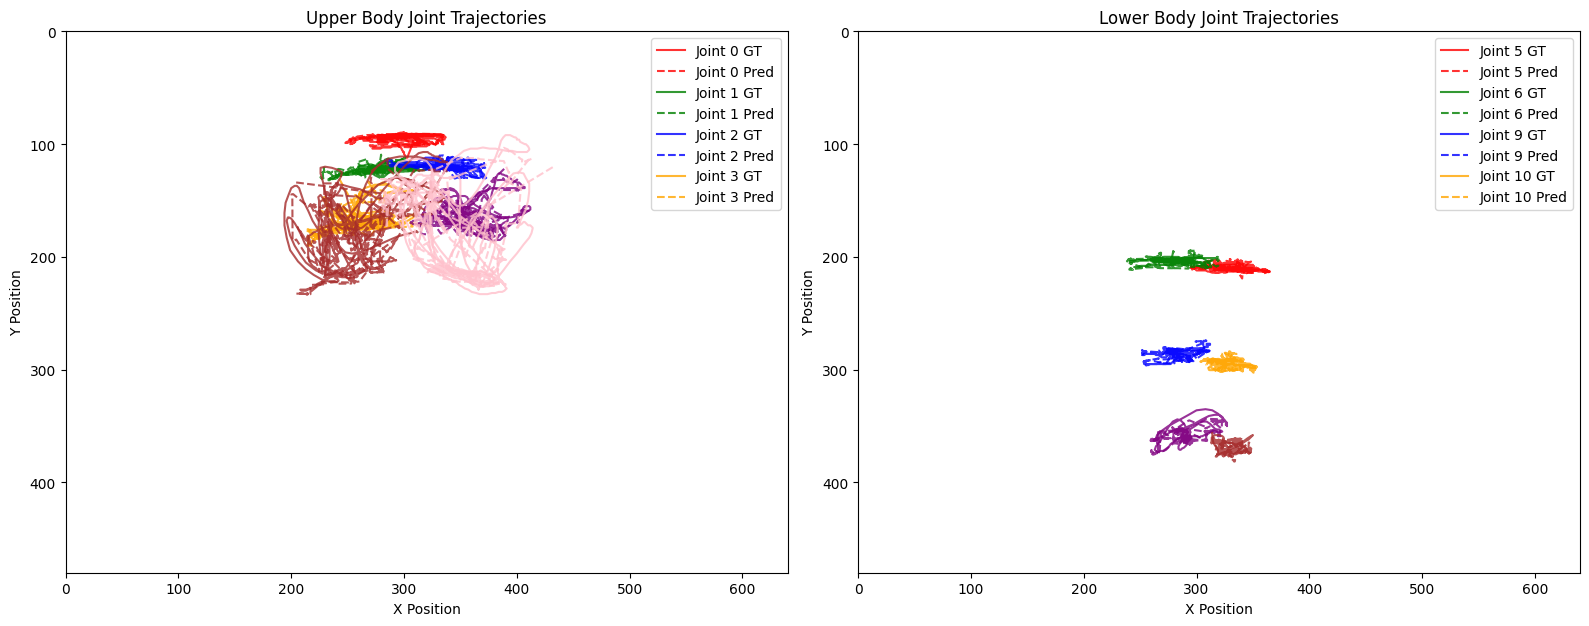

In [10]:
# Define upper and lower body joints
upper_joints = [0, 1, 2, 3, 4, 7, 8]  # Head, shoulders, elbows, wrists
lower_joints = [5, 6, 9, 10, 11, 12]  # Hips, knees, ankles

colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Upper body trajectories
ax1.set_title('Upper Body Joint Trajectories')
for i, j in enumerate(upper_joints):
    color = colors[i % len(colors)]
    ax1.plot(joints_gt[:, j, 0], joints_gt[:, j, 1], color=color, linestyle='-', label=f'Joint {j} GT' if i < 4 else "", alpha=0.8)
    ax1.plot(joints_pred[:, j, 0], joints_pred[:, j, 1], color=color, linestyle='--', label=f'Joint {j} Pred' if i < 4 else "", alpha=0.8)
ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.legend()
ax1.set_aspect('equal')
ax1.invert_yaxis()
ax1.set_xlim(0, 640)
ax1.set_ylim(480, 0)

# Lower body trajectories
ax2.set_title('Lower Body Joint Trajectories')
for i, j in enumerate(lower_joints):
    color = colors[i % len(colors)]
    ax2.plot(joints_gt[:, j, 0], joints_gt[:, j, 1], color=color, linestyle='-', label=f'Joint {j} GT' if i < 4 else "", alpha=0.8)
    ax2.plot(joints_pred[:, j, 0], joints_pred[:, j, 1], color=color, linestyle='--', label=f'Joint {j} Pred' if i < 4 else "", alpha=0.8)
ax2.set_xlabel('X Position')
ax2.set_ylabel('Y Position')
ax2.legend()
ax2.set_aspect('equal')
ax2.invert_yaxis()
ax2.set_xlim(0, 640)
ax2.set_ylim(480, 0)

plt.tight_layout()
plt.show()